In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('data/county_data.pkl', 'rb') as f:
    city_data = pickle.load(f)
def hasna(p):
    return any(np.isnan(x) for x in p)
city_data = {k: v for k, v in city_data.items() if not hasna(v['params'])}
city_data_l = list(city_data.items())

import random
import numpy as np  
random.seed(42)
np.random.seed(42)

def softmax(x):
    return np.exp(x) / (1 + np.exp(x))

population_vals = np.array([e[1]['params'][0] for e in city_data_l])
p_weighting = lambda x: 2*(softmax(((x/2e6)))-0.5)
p_weights = np.array([p_weighting(x) for x in population_vals])
had_event = np.array([len(city_data['events']) > 0 for _, city_data in city_data_l])
sum_no_event = p_weights[~had_event].sum()
num_event = had_event.sum()
target_dataset_size = 450
scale_factor = (target_dataset_size - num_event) / sum_no_event
p_sample_probs = p_weights * scale_factor
p_sample_probs[had_event] = 1.0  # Ensure cities with events are always selected
p_sample_probs = np.clip(p_sample_probs, 0, 1)  # Ensure probabilities are between 0 and 1

population_dens_vals = np.array([e[1]['params'][1] for e in city_data_l])
pdens_weighting = lambda x: 2*(softmax(((x/5e5)))-0.5)
pdens_weights = np.array([pdens_weighting(x) for x in population_dens_vals])
sum_no_event = pdens_weights[~had_event].sum()
num_event = had_event.sum()
scale_factor = (target_dataset_size - num_event) / sum_no_event
pden_sample_probs = pdens_weights * scale_factor
pden_sample_probs[had_event] = 1.0  # Ensure cities with events are always selected
pden_sample_probs = np.clip(pden_sample_probs, 0, 1)  # Ensure probabilities are between 0 and 1


gun_dens_vals = np.array([e[1]['params'][2] for e in city_data_l])
gdens_weighting = lambda x: 2*(softmax(((x/1e3)))-0.5) #adjust for gun density
gdens_weights = np.array([gdens_weighting(x) for x in gun_dens_vals])
sum_no_event = gdens_weights[~had_event].sum()
num_event = had_event.sum()
scale_factor = (target_dataset_size - num_event) / sum_no_event
gun_sample_probs = gdens_weights * scale_factor
gun_sample_probs[had_event] = 1.0  # Ensure cities with events are always selected
gun_sample_probs = np.clip(gun_sample_probs, 0, 1)  # Ensure probabilities are between 0 and 1

print(f"Scale factor: {scale_factor}, Total sample probability: {gun_sample_probs.sum()}")
print(gun_sample_probs.sum())
print(gun_sample_probs.max())

#add all three sample probability together and divide by 3
sample_probs = (p_sample_probs + gun_sample_probs + gun_sample_probs)/3
subsampled_mask = np.random.uniform(0, 1, sample_probs.shape) < sample_probs
print(f"Combined sample probabilities sum: {sample_probs.sum()}")

city_data_l = np.array(city_data_l, dtype=object)
subsampled_city_data = city_data_l[subsampled_mask]
subsampled_city_data_names = np.array([e[0] for e in subsampled_city_data])

Scale factor: 0.8057561043437439, Total sample probability: 450.0
450.0
1.0
Combined sample probabilities sum: 436.1444048087004


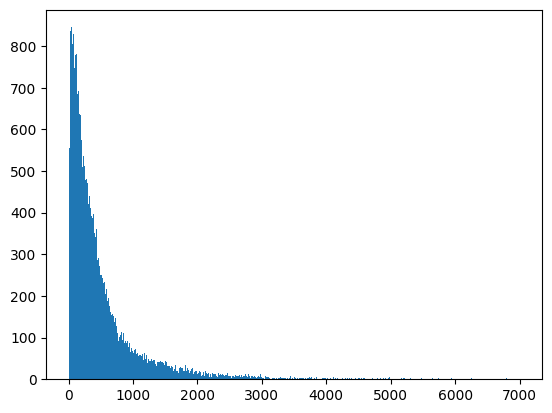

In [7]:
plt.hist(population_dens_vals, bins=np.linspace(0, 7000, 500))
plt.show()

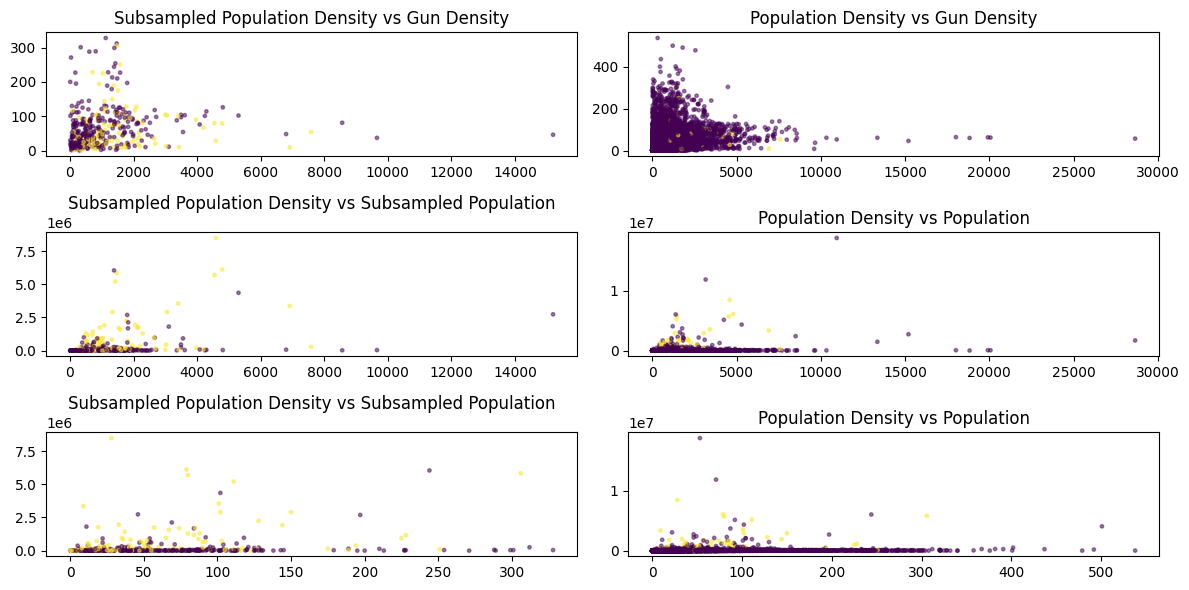

In [25]:
subsampled_mask = np.random.uniform(0, 1, sample_probs.shape) < sample_probs
subsampled_population_dens = population_dens_vals[subsampled_mask]
subsampled_gun_dens = gun_dens_vals[subsampled_mask]
subsampled_pop = population_vals[subsampled_mask]
subsampled_had_event = had_event[subsampled_mask]

fig, ax = plt.subplots(3, 2, figsize=(12, 6))
ax[0, 0].set_title('Subsampled Population Density vs Gun Density')
ax[0, 1].set_title('Population Density vs Gun Density')
ax[0, 0].scatter(subsampled_population_dens, subsampled_gun_dens, alpha=0.5, c=subsampled_had_event, s=6)
ax[0, 1].scatter(population_dens_vals, gun_dens_vals, alpha=0.5, c=had_event, s=6)

ax[1, 0].set_title('Subsampled Population Density vs Subsampled Population')
ax[1, 1].set_title('Population Density vs Population')
ax[1, 0].scatter(subsampled_population_dens, subsampled_pop, alpha=0.5, c=subsampled_had_event, s=6)
ax[1, 1].scatter(population_dens_vals, population_vals, alpha=0.5, c=had_event, s=6)

ax[2, 0].set_title('Subsampled Population Density vs Subsampled Population')
ax[2, 1].set_title('Population Density vs Population')
ax[2, 0].scatter(subsampled_gun_dens, subsampled_pop, alpha=0.5, c=subsampled_had_event, s=6)
ax[2, 1].scatter(gun_dens_vals, population_vals, alpha=0.5, c=had_event, s=6)
fig.tight_layout()

In [ ]:

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('data/county_data.pkl', 'rb') as f:
    city_data = pickle.load(f)
def hasna(p):
    return any(np.isnan(x) for x in p)
city_data = {k: v for k, v in city_data.items() if not hasna(v['params'])}

# city_data_f = [c for c in city_data.values() if c['events']]
# city_data_base = [c for c in city_data.values() if not c['events']]
# city_data_f_names = [c for c, d in city_data.items() if d['events']]
# city_data_base_names = [c for c, d in city_data.items() if not d['events']]
# city_base_ind = np.arange(len(city_data_base))
# np.random.seed(1)
# np.random.shuffle(city_base_ind)
# subsampled_city_data_base = np.array(city_data_base)[city_base_ind[:400]]
# subsampled_city_data_base_names = np.array(city_data_base_names)[city_base_ind[:400]]
# subsampled_city_data = np.concatenate([city_data_f, subsampled_city_data_base])
# subsampled_city_data_names = np.concatenate([city_data_f_names, subsampled_city_data_base_names])
# base_weight = len(city_data_base) / 400
# subsample_weights = np.array([1+base_weight*(len(c['events']) == 0) for c in subsampled_city_data])

In [3]:
city_data_l = list(city_data.items())


In [4]:
ex_data = [x for x in city_data_l if x[1]['events']][0]
ex_data

('San Jose, California',
 {'events': [EventOutcome(date='5/26/21', fatalities=9, injured=0, total_victims=9)],
  'params': CityParams(population=1771563, population_density=2148.3, arm_count=10.0, arm_density=0.012126579749069043)})

In [5]:
from param_distr import ParamDistr, param_config
import jax.random as jrand
distr = ParamDistr(param_config)
general_params = distr.transform_sample(distr.sample_range(jrand.PRNGKey(0)))

In [6]:
general_params

Array([6.1754413e-06, 9.2986511e+01, 2.1338603e-02, 8.6563921e-01,
       1.9035080e-06], dtype=float32)

In [7]:
from abm_event import conditional_sample
samples = conditional_sample(city_params=ex_data[1]['params'], general_params=general_params, rng_key=jrand.PRNGKey(1), num_samples=10000)

In [8]:
from stat_utils import grenander_pdf
pdf = grenander_pdf(samples+1)

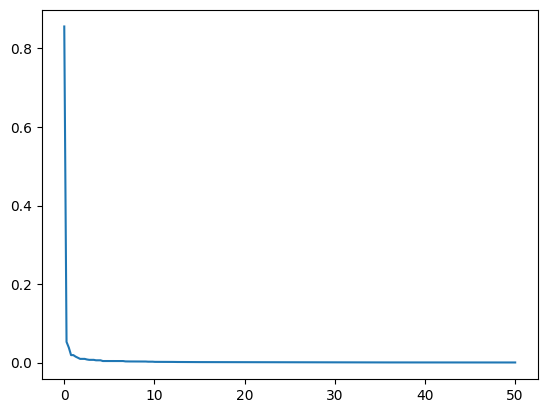

In [9]:
x = np.linspace(0, 50, 200)
pdf_eval = pdf.pdf(x+1)
plt.plot(x, pdf_eval)

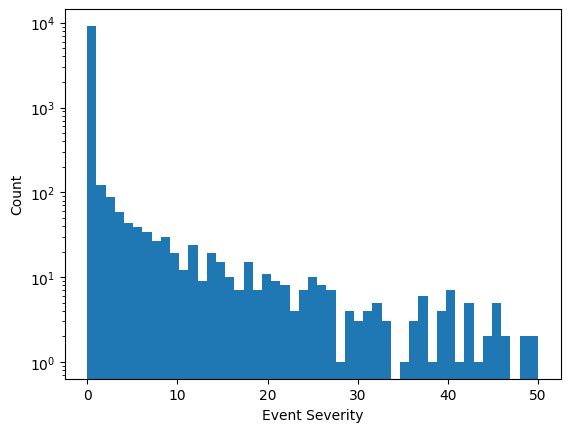

In [10]:
import matplotlib.pyplot as plt
plt.hist(samples, bins=np.linspace(0, 50, 50))
plt.yscale('log')
plt.xlabel('Event Severity')
plt.ylabel('Count')
plt.show()

(array([2.3629e+04, 1.8230e+03, 7.2300e+02, 3.7200e+02, 2.0000e+02,
        1.3900e+02, 1.2100e+02, 1.0700e+02, 6.6000e+01, 5.5000e+01,
        4.7000e+01, 4.5000e+01, 2.7000e+01, 2.1000e+01, 2.8000e+01,
        1.6000e+01, 1.8000e+01, 1.1000e+01, 9.0000e+00, 1.6000e+01,
        1.4000e+01, 1.0000e+01, 9.0000e+00, 5.0000e+00, 8.0000e+00,
        8.0000e+00, 4.0000e+00, 9.0000e+00, 7.0000e+00, 6.0000e+00,
        5.0000e+00, 5.0000e+00, 5.0000e+00, 3.0000e+00, 4.0000e+00,
        4.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00,
        6.0000e+00, 1.0000e+00, 1.0000e+00, 4.0000e+00, 2.0000e+00,
        5.0000e+00, 2.0000e+00, 0.0000e+00, 2.0000e+00, 3.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        2.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 2.0000e+00,
        1.0000e+00, 2.0000e+00, 3.0000e+00, 2.0000e+00, 1.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 2.0000e+00, 0.0000e+00, 1.00

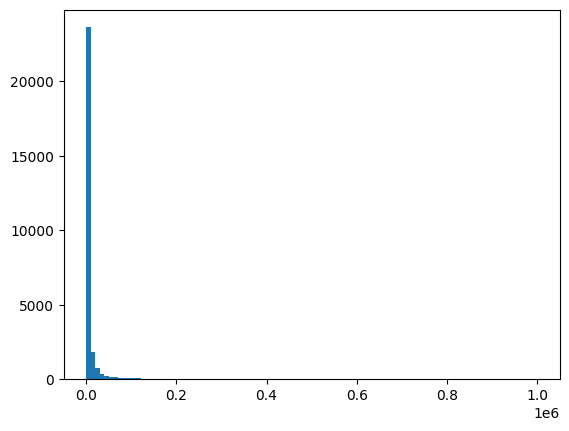

In [11]:
population_vals = np.array([e['params'][0] for e in city_data.values()])
plt.hist(population_vals, bins=np.linspace(0, 1e6, 100))

In [12]:
def softmax(x):
    return np.exp(x) / (1 + np.exp(x))
population_weighting = lambda x: 2*(softmax(x/1e5) - 0.5)
population_weights = [population_weighting(x) for x in population_vals]

Text(0, 0.5, 'probability')

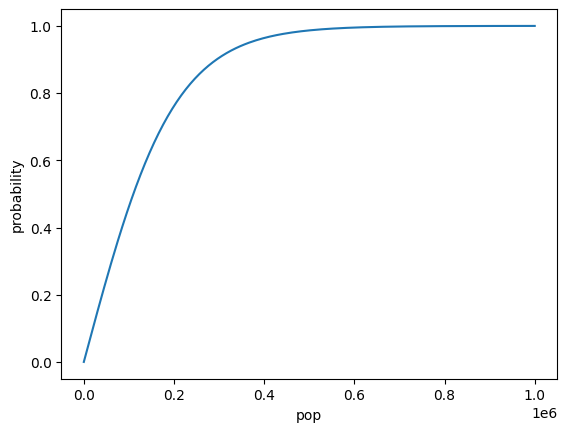

In [13]:
x = np.linspace(0, 1e6, 200)
plt.plot(x, population_weighting(x))
plt.xlabel('pop')
plt.ylabel('probability')

In [14]:
def prob_select(city_data):
    if(len(city_data['events']) > 0):
        return 1
    return population_weighting(city_data['params'][0])
x_select_prob = np.array([prob_select(city_data) for _, city_data in city_data_l])
subsampled_mask = np.random.uniform(0, 1, x_select_prob.shape) < x_select_prob
subsampled_populations = population_vals[subsampled_mask]
x_select_prob.sum(), subsampled_mask.sum(), np.max(1/x_select_prob[subsampled_mask])

(np.float64(1111.3262019473677), np.int64(1137), np.float64(1801.801986801597))